# Titanic

*Ideas and almost all code was taker from* [this notebook](https://www.kaggle.com/code/ash316/eda-to-prediction-dietanic#Analysing-The-Features)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import objects.datasets
from config import config

В коде я пытался устранить возможную утечку данных, поэтому преимущественно исследовал данные из тренировочного датасета.

In [13]:
data = pd.read_csv(config.paths.titanic_train)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

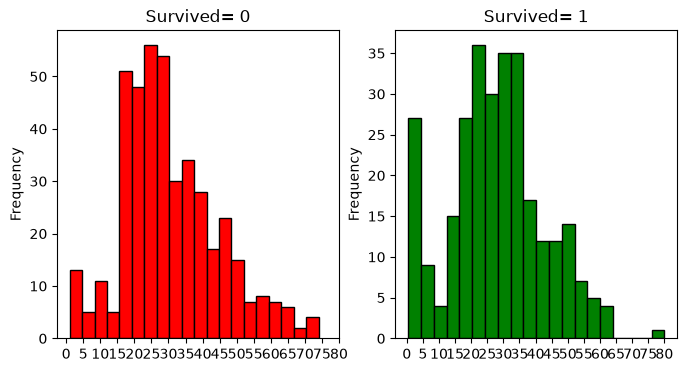

In [17]:
f,ax=plt.subplots(1,2,figsize=(20,10))
data[data['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red', figsize=(8,4))
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
data[data['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black', figsize=(8,4))
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

Возраст пассажиров можно расценивать как одну из наиболее важных фичей, поскольку принцип отбора людей на спасательные шлюпки звучит как *The Women and Child First Policy*. Возрастное распределение в целом подтверждает что дети были приоритетными для спасения пассажирами. 

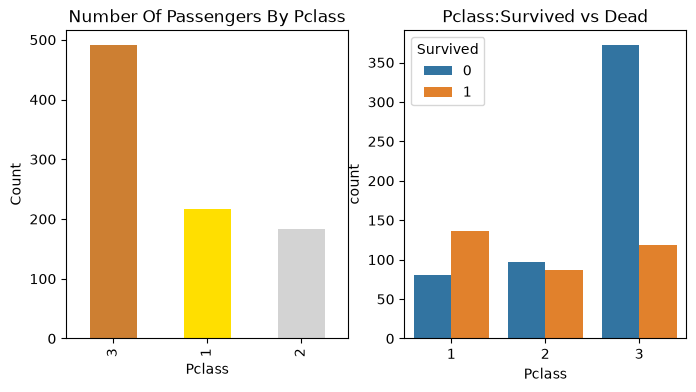

In [34]:
f,ax=plt.subplots(1,2,figsize=(8,4))
data['Pclass'].value_counts().plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'],ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
sns.countplot(x='Pclass',hue='Survived',data=data,ax=ax[1])
ax[1].set_title('Pclass:Survived vs Dead')
plt.show()

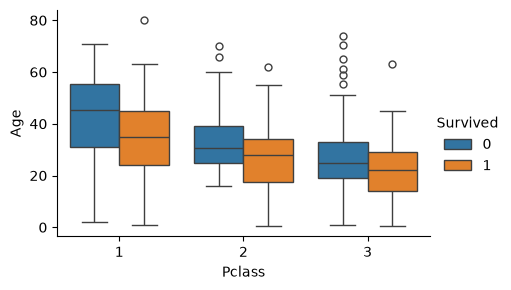

In [ ]:
sns.catplot(x='Pclass', y='Age', hue='Survived', data=data, height=3, aspect=1.5, kind='box')
plt.show()

Из столбчатой диаграммы можно заключить, что пассажиры первого класса так же были в приоритете на спасение, причём по коробке с усами видно, что предпочтение отдавалось более молодым из них.

### Заполнение пропусков

Для заполнения пропусков данных необходимо найти способ определения приблизительного возраста пассажира и распределение пассажиров по их портам отправлений (колонка `Embarked`).
Из среза датафрейма заметно, что преимущественно все пасажиры имеют инициалы, указывающие на их статус (`Mr`, `Mrs`, `Miss`). Инициалы можно использовать как метку, указывающую на приблизительный возраст пассажира.

In [49]:
data['Initial']=0
for i in data:
    data['Initial']=data.Name.str.extract('([A-Za-z]+)\.')

pd.crosstab(data.Initial,data.Sex).T

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


Заметно что у пассажиров инициалы разнородные и одни и те же записаны по разному (`Mlle`, `Mme`, `Ms` == `Miss` и т.д.), поэтому желательно привести их к единообразию 

In [50]:
data['Initial'] = data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'], \
                        ['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'])

data.groupby('Initial')['Age'].mean()

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

Такими средними значениями можно заполнить пропуски в колонке `Age`. Особенно полезным оказался инициал `Master`, относящийся к мальчикам до 12 лет. 

In [51]:
data.loc[(data['Embarked'].isnull())]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,Miss
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,Mrs


Оба пропуска `Embarked` относятся к пассажирам первого класса, поэтому логично заполнить их наиболее вероятным значением для представителей этого (как и любого другого) класса.

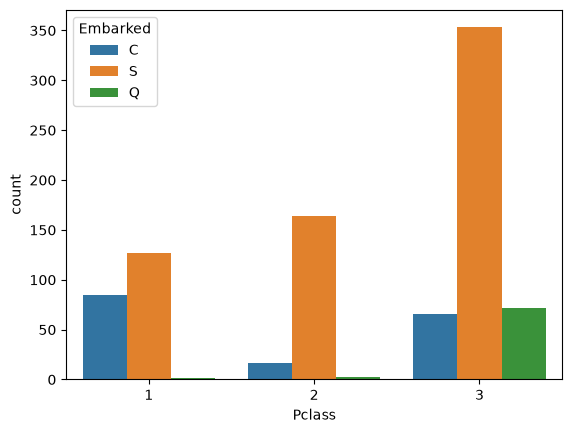

In [58]:
sns.countplot(x='Pclass',hue='Embarked',data=data)
plt.show()

# House prices

*Ideas and almost all code was taken from* [this notebook](https://www.kaggle.com/code/machanif/eda-hunting-for-missing-values)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import config
import utils

train_df = pd.read_csv(config.paths.houses_train)
test_df = pd.read_csv(config.paths.houses_test)

In [11]:
train_null_columns = utils.check_nulls(train_df)
print(train_null_columns, '\n======\nshape:', train_null_columns.shape)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64 
shape: (19,)


In [12]:
test_null_columns = utils.check_nulls(test_df)
print(test_null_columns, '\n======\nshape:', test_null_columns.shape)

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageYrBlt       78
GarageCond        78
GarageFinish      78
GarageQual        78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
BsmtHalfBath       2
Utilities          2
Functional         2
BsmtFullBath       2
BsmtFinSF1         1
Exterior1st        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
SaleType           1
KitchenQual        1
GarageCars         1
GarageArea         1
Exterior2nd        1
dtype: int64 
shape: (33,)


### Корреляция/связь между фичами и таргетом

In [2]:
correlation = train_df[config.num_features.houses].drop(columns=[config.targets.houses]).corrwith(train_df[config.targets.houses])
print(correlation[(correlation >= 0.5) | (correlation <= -0.5)])

OverallQual     0.790982
YearBuilt       0.522897
YearRemodAdd    0.507101
TotalBsmtSF     0.613581
1stFlrSF        0.605852
GrLivArea       0.708624
FullBath        0.560664
TotRmsAbvGrd    0.533723
GarageCars      0.640409
GarageArea      0.623431
dtype: float64


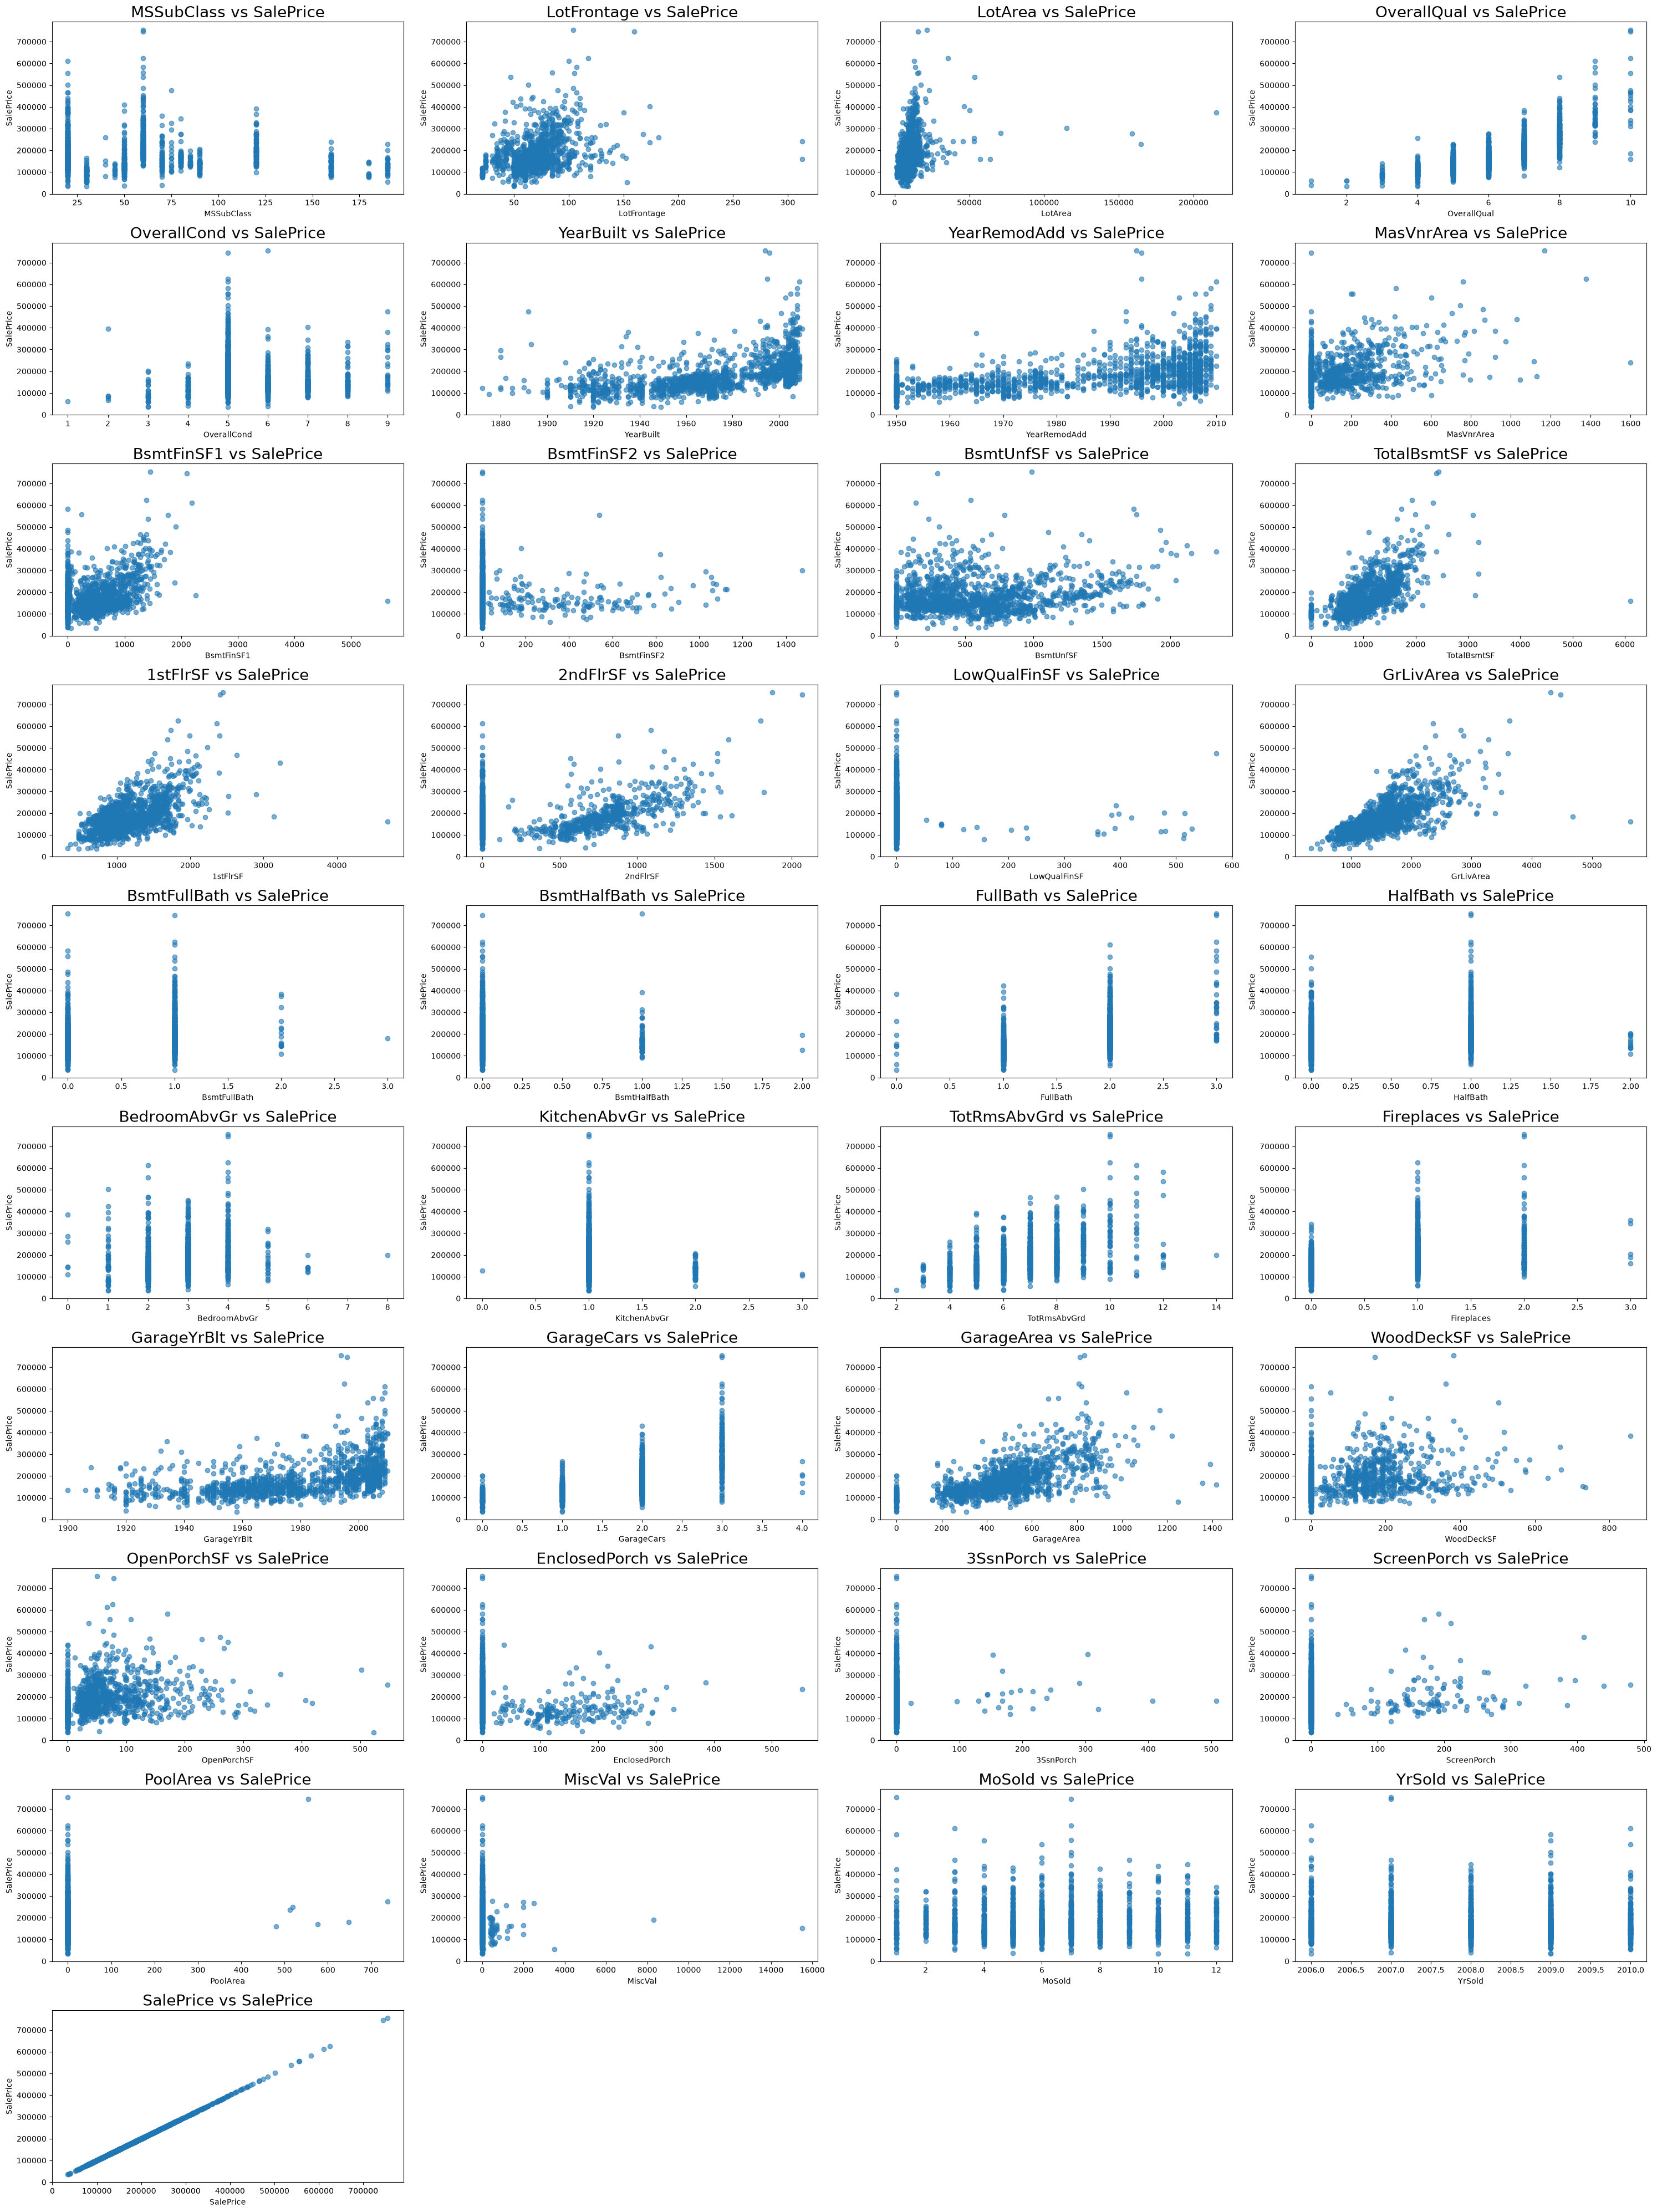

In [5]:
target_col = config.targets.houses
feature_cols = config.num_features.houses

n_features = len(feature_cols)
n_cols = 4  # 4 plots per row, adjust as needed
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(train_df[col], train_df[target_col], alpha=0.6)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].set_title(f'{col} vs {target_col}', fontsize = 20)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

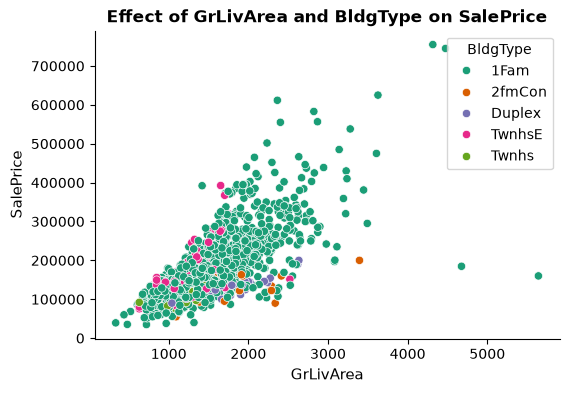

BldgType: Type of dwelling:
	1Fam	Single-family Detached
	2FmCon Two-family Conversion originally built as one-family dwelling
	Duplex
	TwnhsE	Townhouse End Unit
	TwnhsI Townhouse Inside Unit


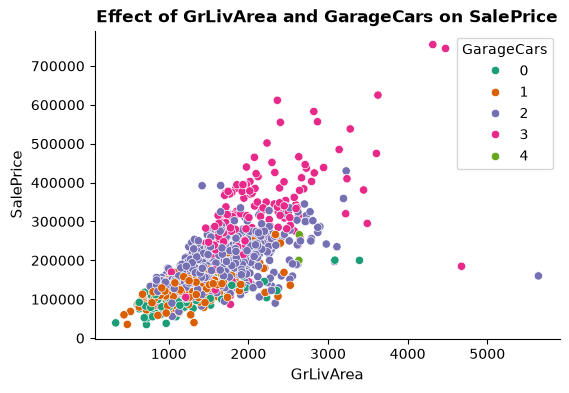

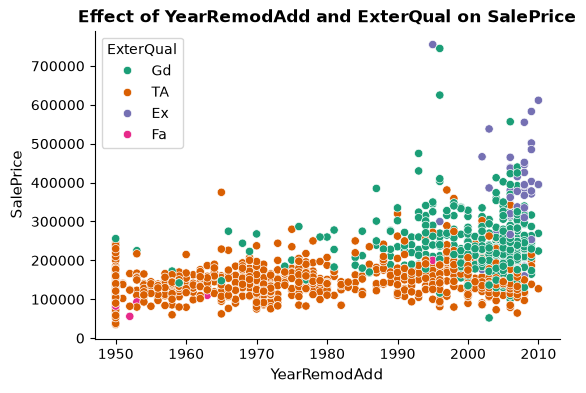

ExterQual: Evaluates the quality of the material on the exterior


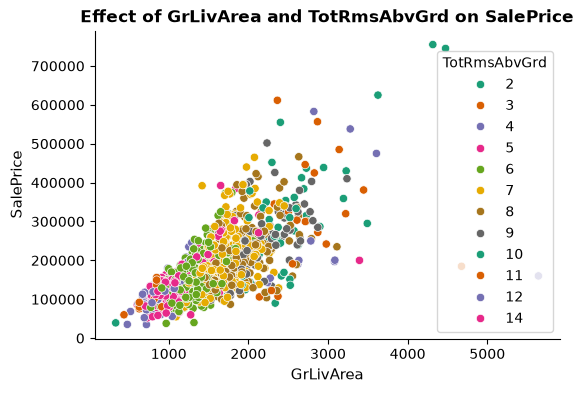

TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)


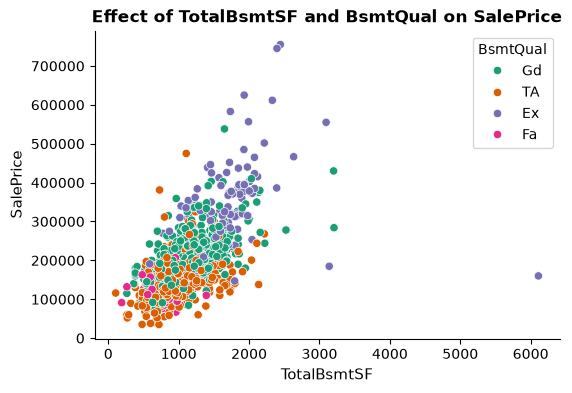

TotalBsmtSF: Total square feet of basement area


In [6]:
utils.visualize_target_dependency(train_df, "GrLivArea", "SalePrice", "BldgType")
print('BldgType: Type of dwelling:\n\t1Fam	Single-family Detached' \
    '\n\t2FmCon Two-family Conversion originally built as one-family dwelling\n\tDuplex' \
    '\n\tTwnhsE	Townhouse End Unit\n\tTwnhsI Townhouse Inside Unit')

utils.visualize_target_dependency(train_df, "GrLivArea", "SalePrice", "GarageCars")

utils.visualize_target_dependency(train_df, "YearRemodAdd", "SalePrice", "ExterQual")
print('ExterQual: Evaluates the quality of the material on the exterior')

utils.visualize_target_dependency(train_df, "GrLivArea", "SalePrice", "TotRmsAbvGrd")
print('TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)')

utils.visualize_target_dependency(train_df, "TotalBsmtSF", "SalePrice", "BsmtQual")
print('TotalBsmtSF: Total square feet of basement area')

### Заполнение пропусков

In [45]:
cat_df = train_df[config.cat_features.houses]
cat_df.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
1,RL,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
2,RL,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
3,RL,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,None,None,None,WD,Abnorml
4,RL,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal


In [46]:
utils.check_nulls(cat_df)

Electrical    1
dtype: int64

Как указано в описании датасета, здесь NaN у всех фичей означает, что у данного конкретно семпла такой фичи просто нет. Поэтому у категориальных фичей пропуски будут заменены на `None`, а у численных на `0` 

In [47]:
train_df['PoolQC'] = train_df['PoolQC'].fillna('None')
train_df['MasVnrType'] = train_df['MasVnrType'].fillna('None')
train_df['FireplaceQu'] = train_df['FireplaceQu'].fillna('None')
train_df[['GarageQual', 'GarageType', 'GarageFinish', 'GarageCond']] = train_df[[
    'GarageQual', 'GarageType', 'GarageFinish', 'GarageCond']].fillna('None')
train_df[['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']] = train_df[[
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']].fillna('None')
train_df[['MiscFeature', 'Alley', 'Fence']] = train_df[['MiscFeature', 'Alley', 'Fence']].fillna('None')

In [48]:
cat_df = train_df[config.cat_features.houses]
utils.check_nulls(cat_df)

Electrical    1
dtype: int64

У единственного дома с пропуком в фиче электропроводки можно увидеть, что подключены все коммунальные услуги (`Utilities` == `AllPub`). Соответственно, электричество в доме всё же есть, поэтому можно записать туда стандартный тип электропроводки

In [49]:
train_df[train_df['Electrical'].isna() == True]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,1380,80,RL,73.0,9735,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2008,WD,Normal,167500


In [52]:
train_df['Electrical'] = train_df['Electrical'].fillna('SBrkr')

In [53]:
cat_df = train_df[config.cat_features.houses]
utils.check_nulls(cat_df)

Series([], dtype: int64)